## EDA for netload and nasa merge dataset

In [4]:
import sys, pandas as pd, numpy as np, matplotlib
print("Python:", sys.version)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("matplotlib:", matplotlib.__version__)

Python: 3.12.12 | packaged by conda-forge | (main, Oct 22 2025, 23:13:34) [MSC v.1944 64 bit (AMD64)]
pandas: 2.3.3
numpy: 2.4.0
matplotlib: 3.10.8


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "../data/processed/netload/f10_netload_nasa_clean.csv"

df = pd.read_csv(DATA_PATH)
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.sort_values("Timestamp").reset_index(drop=True)

df.head()

,Timestamp,MW_raw,NetLoad_MW,ALLSKY_SFC_SW_DWN,T2M,WS10M
0,2025-03-31 15:45:00,1.356,-1.356,425.48,31.07,3.42
1,2025-03-31 16:00:00,0.353,-0.353,194.80,30.73,3.49
2,2025-03-31 16:15:00,-0.509,0.509,194.80,30.73,3.49
3,2025-03-31 16:30:00,-1.902,1.902,194.80,30.73,3.49
4,2025-03-31 16:45:00,-2.148,2.148,194.80,30.73,3.49


### basic info and checks

In [6]:
print("Rows:", len(df))
print("Date range:", df["Timestamp"].min(), "→", df["Timestamp"].max())
print("\nColumns:", df.columns.tolist())

df.info()
df.describe(include="all")

Rows: 14784
Date range: 2025-03-31 15:45:00 → 2025-09-01 15:30:00

Columns: ['Timestamp', 'MW_raw', 'NetLoad_MW', 'ALLSKY_SFC_SW_DWN', 'T2M', 'WS10M']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14784 entries, 0 to 14783
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Timestamp          14784 non-null  datetime64[ns]
 1   MW_raw             14784 non-null  float64       
 2   NetLoad_MW         14784 non-null  float64       
 3   ALLSKY_SFC_SW_DWN  14784 non-null  float64       
 4   T2M                14784 non-null  float64       
 5   WS10M              14784 non-null  float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 693.1 KB


,Timestamp,MW_raw,NetLoad_MW,ALLSKY_SFC_SW_DWN,T2M,WS10M
count,14784,14784.000000,14784.000000,14784.000000,14784.000000,14784.000000
mean,2025-06-16 15:37:30,-4.084276,4.084276,241.764535,29.567264,6.386087
min,2025-03-31 15:45:00,-12.617000,-9.365000,0.000000,26.470000,0.130000
25%,2025-05-09 03:41:15,-7.706250,-0.155500,0.000000,28.800000,4.610000
50%,2025-06-16 15:37:30,-6.396000,6.396000,16.895000,29.440000,6.330000
75%,2025-07-25 03:33:45,0.155500,7.706250,507.460000,30.360000,8.190000
max,2025-09-01 15:30:00,9.365000,12.617000,991.030000,32.740000,14.020000
std,NaN,5.357277,5.357277,313.772143,1.111526,2.597689


### missing values and duplicates

In [7]:
print("Missing values per column:")
print(df.isna().sum().sort_values(ascending=False))

dup_ts = df["Timestamp"].duplicated().sum()
print("\nDuplicate timestamps:", dup_ts)

Missing values per column:
Timestamp            0
MW_raw               0
NetLoad_MW           0
ALLSKY_SFC_SW_DWN    0
T2M                  0
WS10M                0
dtype: int64

Duplicate timestamps: 0


### interval / gap check (should be 15 min)

In [8]:
dt = df["Timestamp"].diff()
gaps = df.loc[(dt.notna()) & (dt != pd.Timedelta(minutes=15)), ["Timestamp"]]
print("True non-15min steps:", len(gaps))
gaps.head(20)

True non-15min steps: 0


,Timestamp


## Plot the key time series

### NetLoad over full period

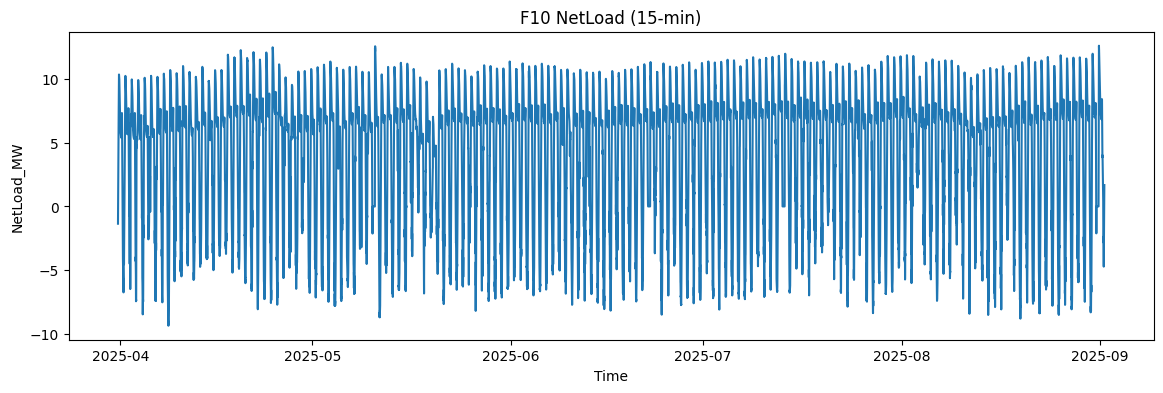

In [9]:
plt.figure(figsize=(14,4))
plt.plot(df["Timestamp"], df["NetLoad_MW"])
plt.title("F10 NetLoad (15-min)")
plt.xlabel("Time"); plt.ylabel("NetLoad_MW")
plt.show()

### NASA features overview

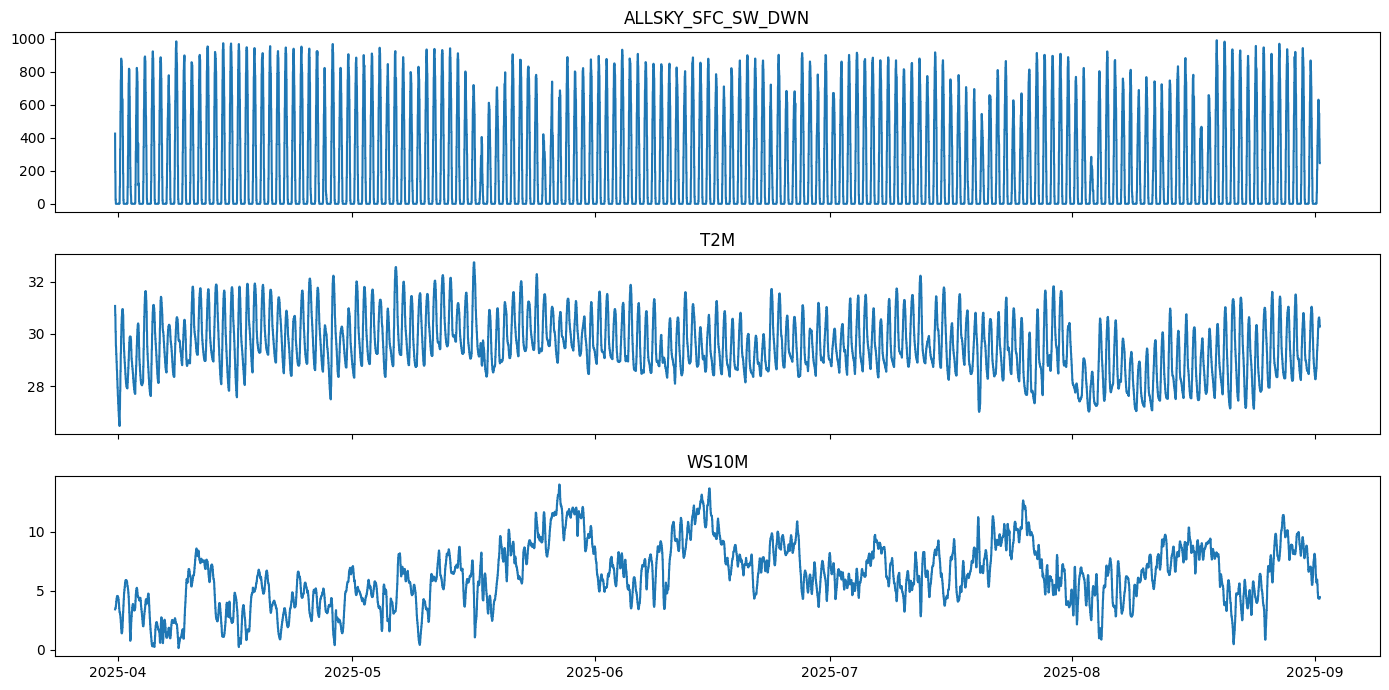

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(14,7), sharex=True)

axes[0].plot(df["Timestamp"], df["ALLSKY_SFC_SW_DWN"])
axes[0].set_title("ALLSKY_SFC_SW_DWN")

axes[1].plot(df["Timestamp"], df["T2M"])
axes[1].set_title("T2M")

axes[2].plot(df["Timestamp"], df["WS10M"])
axes[2].set_title("WS10M")

plt.tight_layout()
plt.show()

## Distribution and outliers

### histograms

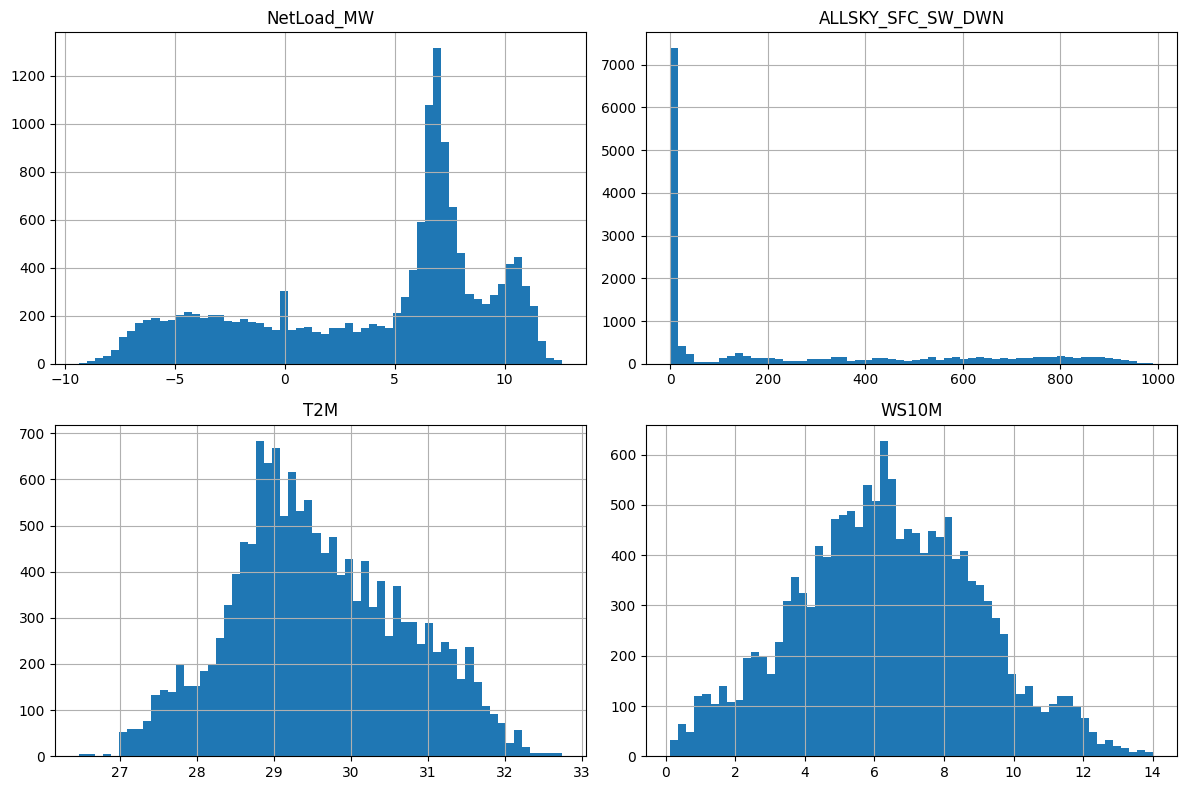

In [11]:
cols = ["NetLoad_MW", "ALLSKY_SFC_SW_DWN", "T2M", "WS10M"]
df[cols].hist(bins=60, figsize=(12,8))
plt.tight_layout()
plt.show()

### quick outlier view (quantiles)

In [12]:
for c in cols:
    q1, q99 = df[c].quantile([0.01, 0.99])
    print(f"{c}: 1%={q1:.3f}, 99%={q99:.3f}, min={df[c].min():.3f}, max={df[c].max():.3f}")

NetLoad_MW: 1%=-7.462, 99%=11.481, min=-9.365, max=12.617
ALLSKY_SFC_SW_DWN: 1%=0.000, 99%=929.081, min=0.000, max=991.030
T2M: 1%=27.240, 99%=31.980, min=26.470, max=32.740
WS10M: 1%=0.848, 99%=12.240, min=0.130, max=14.020


## Relationships (correlation)

### correlation matrix (numeric)

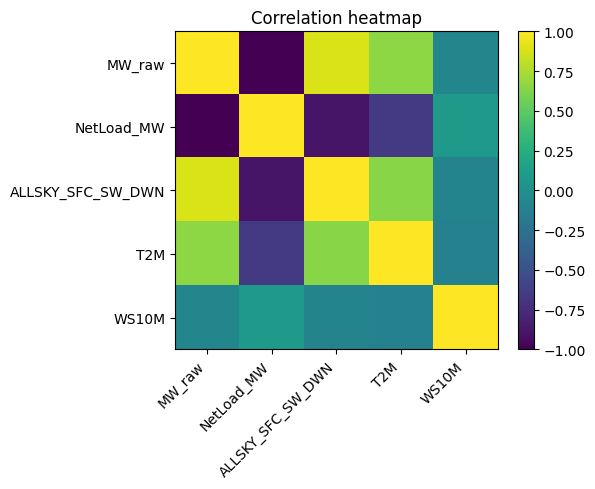

,MW_raw,NetLoad_MW,ALLSKY_SFC_SW_DWN,T2M,WS10M
MW_raw,1.000000,-1.000000,0.885977,0.659407,-0.078817
NetLoad_MW,-1.000000,1.000000,-0.885977,-0.659407,0.078817
ALLSKY_SFC_SW_DWN,0.885977,-0.885977,1.000000,0.643205,-0.101291
T2M,0.659407,-0.659407,0.643205,1.000000,-0.120421
WS10M,-0.078817,0.078817,-0.101291,-0.120421,1.000000


In [13]:
num = df.drop(columns=["Timestamp"]).select_dtypes(include=[np.number])
corr = num.corr()

plt.figure(figsize=(6,5))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar()
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

corr

### Scatter vs NetLoad

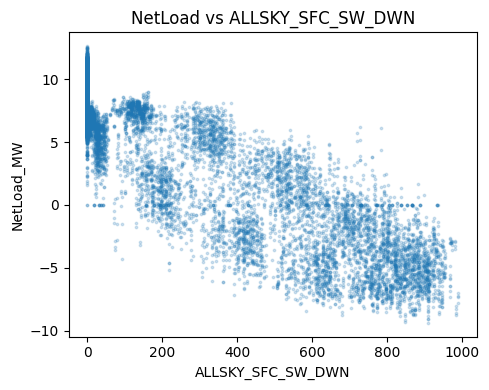

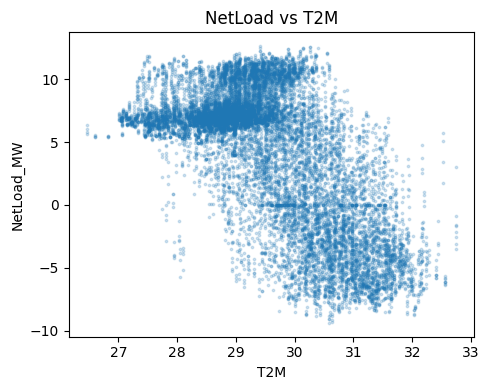

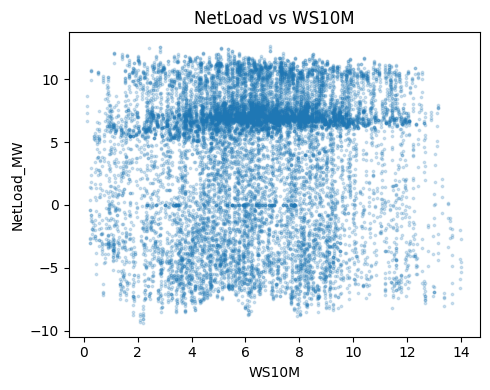

In [14]:
for c in ["ALLSKY_SFC_SW_DWN", "T2M", "WS10M"]:
    plt.figure(figsize=(5,4))
    plt.scatter(df[c], df["NetLoad_MW"], s=3, alpha=0.2)
    plt.xlabel(c); plt.ylabel("NetLoad_MW")
    plt.title(f"NetLoad vs {c}")
    plt.tight_layout()
    plt.show()

## Time features that matter for forecasting (EDA)

### daily pattern (average by time-of-day)

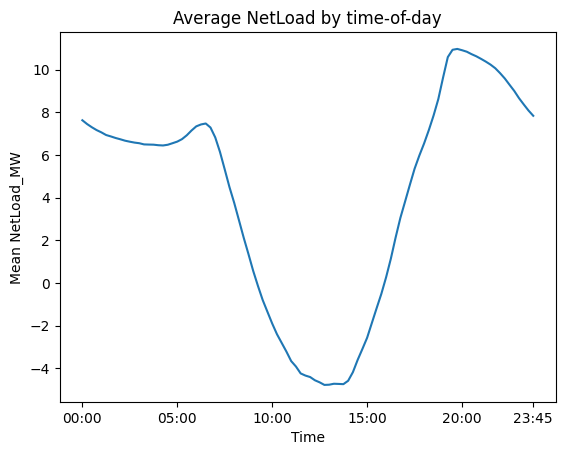

In [15]:
tmp = df.copy()
tmp["bin"] = tmp["Timestamp"].dt.hour*4 + tmp["Timestamp"].dt.minute//15
profile = tmp.groupby("bin")["NetLoad_MW"].mean()

plt.plot(profile.values)
plt.xticks([0,20,40,60,80,95], ["00:00","05:00","10:00","15:00","20:00","23:45"])
plt.title("Average NetLoad by time-of-day")
plt.xlabel("Time"); plt.ylabel("Mean NetLoad_MW")
plt.show()

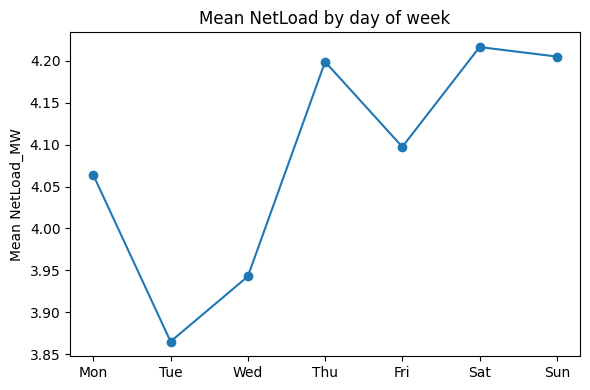

In [16]:
tmp = df.copy()
tmp["dow"] = tmp["Timestamp"].dt.dayofweek  # 0=Mon
dow_mean = tmp.groupby("dow")["NetLoad_MW"].mean()

plt.figure(figsize=(6,4))
plt.plot(dow_mean.index, dow_mean.values, marker="o")
plt.xticks(range(7), ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
plt.title("Mean NetLoad by day of week")
plt.ylabel("Mean NetLoad_MW")
plt.tight_layout()
plt.show()

### Zoom into 2–3 days

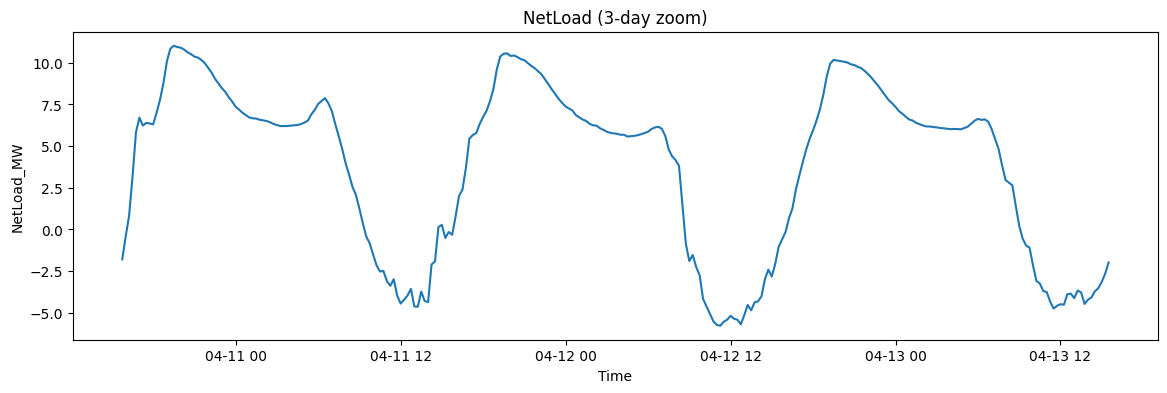

In [17]:
start = df["Timestamp"].min() + pd.Timedelta(days=10)
end = start + pd.Timedelta(days=3)
zoom = df[(df["Timestamp"]>=start) & (df["Timestamp"]<end)]

plt.figure(figsize=(14,4))
plt.plot(zoom["Timestamp"], zoom["NetLoad_MW"])
plt.title("NetLoad (3-day zoom)")
plt.xlabel("Time"); plt.ylabel("NetLoad_MW")
plt.show()

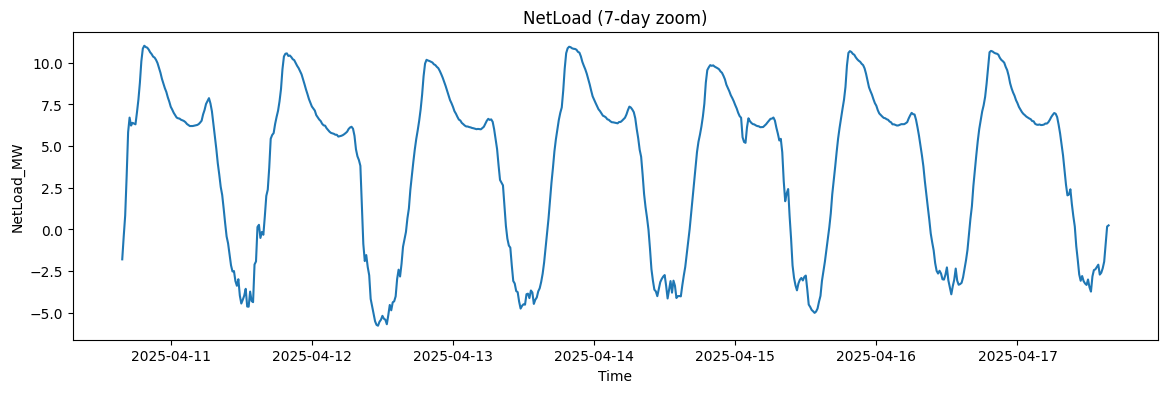

In [18]:
start = df["Timestamp"].min() + pd.Timedelta(days=10)
end = start + pd.Timedelta(days=7)
zoom = df[(df["Timestamp"]>=start) & (df["Timestamp"]<end)]

plt.figure(figsize=(14,4))
plt.plot(zoom["Timestamp"], zoom["NetLoad_MW"])
plt.title("NetLoad (7-day zoom)")
plt.xlabel("Time"); plt.ylabel("NetLoad_MW")
plt.show()